In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = r"..\Dataset\clean_data.csv"
UNCALIBRATED_MODEL_PATH = r"..\models\xgb_pipeline.pkl"
CALIBRATED_MODEL_PATH = r"..\models\calibrated_xgb_pipeline.pkl"

In [3]:
df = pd.read_csv(DATA_PATH)
df.head(5)

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,2278392,8222157,Caucasian,Female,5,Not_Available,Not_Mapped,Physician_Referral,1,41,...,No,No,No,No,No,No,No,No,No,0
1,64410,86047875,AfricanAmerican,Female,25,Emergency,Discharged_Home,Emergency_Room,2,11,...,No,No,No,No,No,No,No,No,Yes,0
2,500364,82442376,Caucasian,Male,35,Emergency,Discharged_Home,Emergency_Room,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,0
3,16680,42519267,Caucasian,Male,45,Emergency,Discharged_Home,Emergency_Room,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,0
4,55842,84259809,Caucasian,Male,65,Elective,Discharged_Home,Clinic_Referral,4,70,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [4]:
def calculate_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0., 1., n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    for i in range(n_bins):
        bin_mask = (binids == i)
        if bin_mask.sum() > 0:
            bin_acc = y_true[bin_mask].mean()
            bin_conf = y_prob[bin_mask].mean()
            bin_weight = bin_mask.sum() / len(y_prob)
            ece += bin_weight * np.abs(bin_acc - bin_conf)

    return ece

In [5]:
X = df.drop(columns=['target', 'encounter_id'])
y = df['target']
groups = df['patient_nbr']

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [6]:
uncalibrated_pipeline = joblib.load(UNCALIBRATED_MODEL_PATH)

# Get baseline probabilities on TEST set
prob_uncalibrated = uncalibrated_pipeline.predict_proba(X_test)[:, 1]
ece_uncalib = calculate_ece(y_test, prob_uncalibrated)
brier_uncalib = brier_score_loss(y_test, prob_uncalibrated)

print(f"--- BASELINE (UNCALIBRATED) ---")
print(f"AUC:   {roc_auc_score(y_test, prob_uncalibrated):.4f}")
print(f"Brier: {brier_uncalib:.4f}")
print(f"ECE:   {ece_uncalib:.4f}  <-- Our goal is to get this ≤ 0.05")

--- BASELINE (UNCALIBRATED) ---
AUC:   0.7362
Brier: 0.1973
ECE:   0.2569  <-- Our goal is to get this ≤ 0.05


In [7]:
print("Fitting Sigmoid (Platt) Calibration...")
calib_sigmoid = CalibratedClassifierCV(estimator=uncalibrated_pipeline, method='sigmoid', cv=5, n_jobs=-1)
calib_sigmoid.fit(X_train, y_train)
prob_sigmoid = calib_sigmoid.predict_proba(X_test)[:, 1]

Fitting Sigmoid (Platt) Calibration...


In [8]:
print("Fitting Isotonic Calibration...")
calib_isotonic = CalibratedClassifierCV(estimator=uncalibrated_pipeline, method='isotonic', cv=5, n_jobs=-1)
calib_isotonic.fit(X_train, y_train)
prob_isotonic = calib_isotonic.predict_proba(X_test)[:, 1]

Fitting Isotonic Calibration...


In [9]:
ece_sig = calculate_ece(y_test, prob_sigmoid)
ece_iso = calculate_ece(y_test, prob_isotonic)

print(f"\n--- SIGMOID (PLATT) ---")
print(f"ECE: {ece_sig:.4f} | Brier: {brier_score_loss(y_test, prob_sigmoid):.4f}")

print(f"\n--- ISOTONIC ---")
print(f"ECE: {ece_iso:.4f} | Brier: {brier_score_loss(y_test, prob_isotonic):.4f}")

# Select the winner based on the blueprint metric (Lowest ECE)
winning_ece = min(ece_sig, ece_iso)
winning_name = "Sigmoid" if winning_ece == ece_sig else "Isotonic"
winning_model = calib_sigmoid if winning_ece == ece_sig else calib_isotonic

print(f"\n🏆 WINNER: {winning_name} Calibration (ECE: {winning_ece:.4f})")


--- SIGMOID (PLATT) ---
ECE: 0.0094 | Brier: 0.1237

--- ISOTONIC ---
ECE: 0.0119 | Brier: 0.1236

🏆 WINNER: Sigmoid Calibration (ECE: 0.0094)


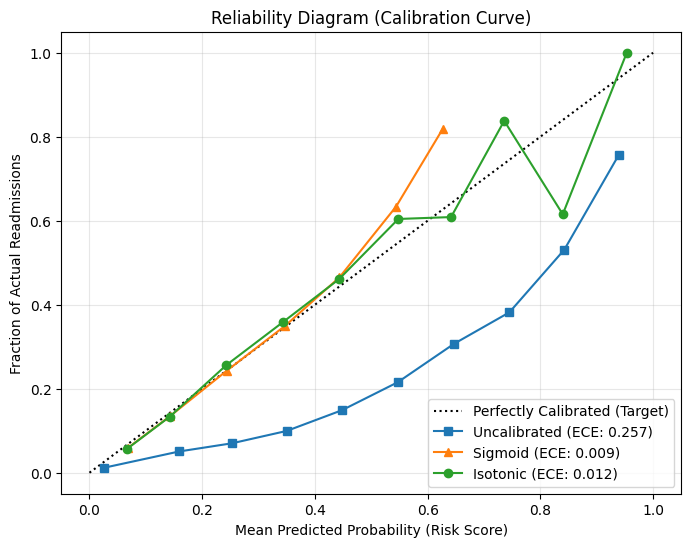

In [10]:
plt.figure(figsize=(8,6))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated (Target)")

# Calculate curve points
frac_pos_uncal, mean_pred_uncal = calibration_curve(y_test, prob_uncalibrated, n_bins=10)
frac_pos_sig, mean_pred_sig = calibration_curve(y_test, prob_sigmoid, n_bins=10)
frac_pos_iso, mean_pred_iso = calibration_curve(y_test, prob_isotonic, n_bins=10)

# Plot curves
plt.plot(mean_pred_uncal, frac_pos_uncal, "s-", label=f"Uncalibrated (ECE: {ece_uncalib:.3f})")
plt.plot(mean_pred_sig, frac_pos_sig, "^-", label=f"Sigmoid (ECE: {ece_sig:.3f})")
plt.plot(mean_pred_iso, frac_pos_iso, "o-", label=f"Isotonic (ECE: {ece_iso:.3f})")

plt.xlabel("Mean Predicted Probability (Risk Score)")
plt.ylabel("Fraction of Actual Readmissions")
plt.title("Reliability Diagram (Calibration Curve)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# Save the winning calibrated model to disk
os.makedirs(os.path.dirname(CALIBRATED_MODEL_PATH), exist_ok=True)
joblib.dump(winning_model, CALIBRATED_MODEL_PATH)

print(f"✓ Calibrated Pipeline ({winning_name}) successfully saved to {CALIBRATED_MODEL_PATH}")
print("Ready for Phase 4: SHAP Explainability!")

✓ Calibrated Pipeline (Sigmoid) successfully saved to ..\models\calibrated_xgb_pipeline.pkl
Ready for Phase 4: SHAP Explainability!
